**Tested Environment:** Python 3.8, PyTorch 1.9.0+

# Why do we need ARC?
Training large AI models can take days or even weeks of expensive GPU time. Because neural networks do millions of calculations a second, a single mathematical error—like a sudden "loss explosion"—can permanently corrupt the model. 

In standard PyTorch, this completely crashes your training. You lose your progress, waste days of compute time, and have to manually restart from scratch. 

**ARC (Autonomous Recovery Controller)** solves this by acting like an automatic airbag. If it detects the math exploding, it instantly catches the error, throws away the corrupted data, rolls back to the last safe step, and seamlessly resumes training—all without a human needing to intervene.

### ARC Quickstart Tutorial
This interactive notebook demonstrates how ARC automatically catches training instabilities (like loss explosions) and rolls back to a safe state without crashing. Let's set up a basic model and protect it with `ArcV2`.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from arc import ArcV2

# 1. Simple Model & Optimizer
model = nn.Linear(10, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 2. Wrap it with the recommended modern API
arc = ArcV2.auto(model, optimizer)

print("ARC Controller Initialized.")

Arc attached to Linear
Device: cpu
Signal collectors: 5
   ARC v2.0 Auto-configured:
   Model: 22 params, 1 layers
   Task: classification
   Safety: standard
   Features: EWC=True, UQ=conformal, Adv=False
ARC Controller Initialized.


### The Training Loop
We will simulate a standard PyTorch training loop for 20 steps. At step 10, we will intentionally inject a massive loss spike to simulate a catastrophic math failure. Watch how ARC handles it!

In [9]:
losses = []
print("Starting training loop...")

for step in range(20):
    x = torch.randn(5, 10, requires_grad=True)
    y = torch.randn(5, 2)
    loss = nn.MSELoss()(model(x), y)
    
    # Force a loss explosion at step 10
    if step == 10:
        print(f"\n[Step {step}] Injecting massive loss spike!")
        loss = loss * 1e10 
        
    # Hand the loss to the ArcV2 controller
    arc.step(loss)
    
    # Standard PyTorch Training Step! ARC protects this silently in the background.
    loss.backward()
    optimizer.step()
    optimizer.zero_grad() 
    
    losses.append(loss.item())
    print(f"Step {step}: Loss = {loss.item():.4f}")

Starting training loop...
Step 0: Loss = 1.3936
Step 1: Loss = 0.8721
Step 2: Loss = 0.5539
Step 3: Loss = 0.9455
Step 4: Loss = 1.4924
Step 5: Loss = 0.5829
Step 6: Loss = 1.9596
Step 7: Loss = 0.3823
Step 8: Loss = 1.0389
Step 9: Loss = 1.1718

[Step 10] Injecting massive loss spike!
Step 10: Loss = 19083507712.0000
Step 11: Loss = 0.7223
Step 12: Loss = 0.8791
Step 13: Loss = 0.7400
Step 14: Loss = 0.8598
Step 15: Loss = 0.6475
Step 16: Loss = 2.5279
Step 17: Loss = 0.7400
Step 18: Loss = 1.1029
Step 19: Loss = 0.8772


### Visualizing the Recovery
Let's plot the loss trajectory to see the exact moment ARC caught the explosion, discarded the corrupted math, and stabilized the training.

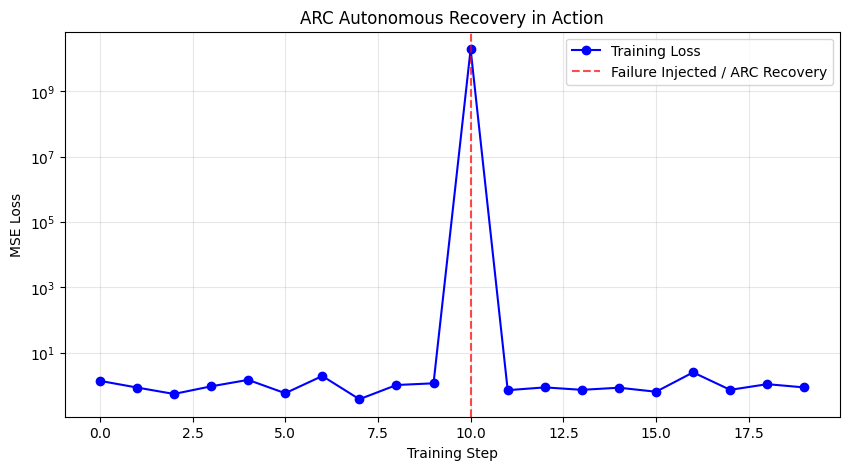

In [10]:
# Plotting the loss trajectory
plt.figure(figsize=(10, 5))
plt.plot(range(20), losses, marker='o', linestyle='-', color='b', label='Training Loss')

plt.axvline(x=10, color='r', linestyle='--', alpha=0.7, label='Failure Injected / ARC Recovery')

plt.title("ARC Autonomous Recovery in Action")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Conclusion: The Value of ARC
Notice the massive loss spike at **Step 10**? 

Normally, a huge error like this would completely ruin your model and force you to restart your training from scratch. 

But because we used ARC, it automatically saved the day:
* **Caught the error** instantly.
* **Threw away** the bad math.
* **Rolled back** to a safe checkpoint.
* **Lowered the learning rate** and kept training!

Using `ArcV2` protects your models from random crashes and saves you days of wasted time. Happy training!